# Bank Marketing EDA



## Mục tiêu của notebook em làm:

- Chọn đúng nhánh dữ liệu trong gói UCI.
- Làm EDA đủ sâu để hỗ trợ phần chọn mô hình ML cơ bản.
- Giải thích được dữ liệu có xu hướng tuyến tính hay phi tuyến, biến nào mạnh, biến nào gây leakage, dữ liệu có mất cân bằng hay drift theo thời gian hay không.
- Đưa ra định hướng rõ ràng cho các bạn làm bước modeling phía sau.

## 1. Imports và cấu hình

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import Image, Markdown, display
from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    # Trong notebook không có __file__, nên fallback về thư mục hiện tại.
    ROOT = Path.cwd()
DATA_PATH = (
    ROOT
    / "bank_marketing_uci"
    / "bank-additional"
    / "bank-additional"
    / "bank-additional-full.csv"
)
OUT_DIR = ROOT / "bank_marketing_eda_outputs"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
REPORT_PATH = ROOT / "BANK_MARKETING_EDA_REPORT.md"

RANDOM_STATE = 42
PLOT_DPI = 160


try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)


## 2. Các hàm hỗ trợ



In [2]:
def ensure_dirs() -> None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_DIR.mkdir(parents=True, exist_ok=True)


def make_ohe() -> OneHotEncoder:
    return OneHotEncoder(handle_unknown="ignore", sparse_output=False)


def markdown_table(df: pd.DataFrame) -> str:
    frame = df.copy()
    headers = [str(col) for col in frame.columns]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for row in frame.itertuples(index=False):
        values = [str(value) for value in row]
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)


def format_table(
    df: pd.DataFrame,
    float_digits: int = 4,
    percent_cols: list[str] | None = None,
) -> pd.DataFrame:
    frame = df.copy()
    percent_cols = percent_cols or []
    for col in frame.columns:
        if col in percent_cols:
            frame[col] = (frame[col] * 100).map(lambda x: f"{x:.2f}%")
        elif pd.api.types.is_float_dtype(frame[col]):
            frame[col] = frame[col].map(lambda x: f"{x:.{float_digits}f}")
    return frame


def load_data() -> pd.DataFrame:
    return pd.read_csv(DATA_PATH, sep=";")


def summarize_unknowns(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.select_dtypes(include="object").columns:
        if col == "y":
            continue
        unknown_count = int((df[col] == "unknown").sum())
        if unknown_count:
            rows.append(
                {
                    "feature": col,
                    "unknown_count": unknown_count,
                    "unknown_rate": unknown_count / len(df),
                }
            )
    return pd.DataFrame(rows).sort_values("unknown_rate", ascending=False)


def summarize_outliers(df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in numeric_cols:
        series = df[col]
        q1, q3 = series.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        is_outlier = (series < lower) | (series > upper)
        rows.append(
            {
                "feature": col,
                "skew": series.skew(),
                "q1": q1,
                "median": series.median(),
                "q3": q3,
                "iqr": iqr,
                "outlier_count_iqr": int(is_outlier.sum()),
                "outlier_rate_iqr": is_outlier.mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("outlier_rate_iqr", ascending=False)


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    phi2 = chi2 / n
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = max(1e-12, min(kcorr - 1, rcorr - 1))
    return float(np.sqrt(phi2corr / denom))


def categorical_association(df: pd.DataFrame, categorical_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in categorical_cols:
        rows.append(
            {
                "feature": col,
                "n_levels": df[col].nunique(),
                "cramers_v": cramers_v(df[col], df["y"]),
            }
        )
    return pd.DataFrame(rows).sort_values("cramers_v", ascending=False)


def numeric_association(df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    frame = df.copy()
    frame["y_bin"] = (frame["y"] == "yes").astype(int)
    mi = mutual_info_classif(frame[numeric_cols], frame["y_bin"], random_state=RANDOM_STATE)
    corr = frame[numeric_cols + ["y_bin"]].corr(numeric_only=True)["y_bin"].drop("y_bin")
    out = pd.DataFrame(
        {
            "feature": numeric_cols,
            "pearson_with_y": [corr[col] for col in numeric_cols],
            "mutual_information": mi,
        }
    )
    return out.sort_values("mutual_information", ascending=False)


def positive_rate_table(df: pd.DataFrame, feature: str, top_n: int | None = None) -> pd.DataFrame:
    frame = df.copy()
    frame["y_bin"] = (frame["y"] == "yes").astype(int)
    table = (
        frame.groupby(feature, observed=False)["y_bin"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "positive_rate", "count": "count"})
        .sort_values("positive_rate", ascending=False)
        .reset_index()
    )
    if top_n is not None:
        table = table.head(top_n)
    return table


def quantile_target_rate(df: pd.DataFrame, feature: str, q: int = 10) -> pd.DataFrame:
    frame = df.copy()
    frame["y_bin"] = (frame["y"] == "yes").astype(int)
    bins = pd.qcut(frame[feature], q=min(q, frame[feature].nunique()), duplicates="drop")
    table = (
        frame.groupby(bins, observed=False)["y_bin"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "positive_rate", "count": "count"})
        .reset_index()
    )
    table["bin"] = table[feature].astype(str)
    return table[["bin", "positive_rate", "count"]]


def custom_binary_target_rate(df: pd.DataFrame, feature_name: str, mask: pd.Series) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            feature_name: np.where(mask, "yes", "no"),
            "y_bin": (df["y"] == "yes").astype(int),
        }
    )
    return (
        frame.groupby(feature_name, observed=False)["y_bin"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "positive_rate", "count": "count"})
        .reset_index()
    )


def compute_vif(df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    rows = []
    X = df[numeric_cols]
    for col in numeric_cols:
        y = X[col]
        X_other = X.drop(columns=[col])
        r2 = LinearRegression().fit(X_other, y).score(X_other, y)
        vif = np.inf if r2 >= 0.999999 else 1.0 / (1.0 - r2)
        rows.append({"feature": col, "vif": vif})
    return pd.DataFrame(rows).sort_values("vif", ascending=False)


def prepare_columns(df: pd.DataFrame, include_duration: bool) -> tuple[list[str], list[str]]:
    features = [col for col in df.columns if col != "y"]
    if not include_duration and "duration" in features:
        features.remove("duration")
    categorical_cols = df[features].select_dtypes(include="object").columns.tolist()
    numeric_cols = [col for col in features if col not in categorical_cols]
    return categorical_cols, numeric_cols


def build_preprocessors(
    categorical_cols: list[str],
    numeric_cols: list[str],
) -> tuple[ColumnTransformer, ColumnTransformer]:
    linear_preprocessor = ColumnTransformer(
        [
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", make_ohe()),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )
    tree_preprocessor = ColumnTransformer(
        [
            (
                "num",
                Pipeline([("imputer", SimpleImputer(strategy="median"))]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", make_ohe()),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )
    return linear_preprocessor, tree_preprocessor


def evaluate_models(df: pd.DataFrame, split_type: str, include_duration: bool) -> pd.DataFrame:
    data = df.drop_duplicates().reset_index(drop=True)
    features = [col for col in data.columns if col != "y"]
    if not include_duration:
        features.remove("duration")

    X = data[features]
    y = (data["y"] == "yes").astype(int)

    if split_type == "time":
        split_idx = int(len(data) * 0.8)
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    elif split_type == "random":
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            stratify=y,
            random_state=RANDOM_STATE,
        )
    else:
        raise ValueError(f"Unsupported split_type: {split_type}")

    categorical_cols, numeric_cols = prepare_columns(data[features + ["y"]], include_duration=include_duration)
    linear_prep, tree_prep = build_preprocessors(categorical_cols, numeric_cols)

    models: dict[str, Pipeline] = {
        "LogisticRegression": Pipeline(
            [
                ("prep", linear_prep),
                (
                    "model",
                    LogisticRegression(max_iter=2000, class_weight="balanced"),
                ),
            ]
        ),
        "KNN": Pipeline(
            [
                ("prep", linear_prep),
                ("model", KNeighborsClassifier(n_neighbors=25)),
            ]
        ),
        "DecisionTree": Pipeline(
            [
                ("prep", tree_prep),
                (
                    "model",
                    DecisionTreeClassifier(
                        random_state=RANDOM_STATE,
                        class_weight="balanced",
                        min_samples_leaf=20,
                    ),
                ),
            ]
        ),
        "RandomForest": Pipeline(
            [
                ("prep", tree_prep),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=300,
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                        class_weight="balanced_subsample",
                        min_samples_leaf=5,
                    ),
                ),
            ]
        ),
        "GradientBoosting": Pipeline(
            [
                ("prep", tree_prep),
                ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
            ]
        ),
    }

    rows = []
    for model_name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        estimator = pipeline.named_steps["model"]
        if hasattr(estimator, "predict_proba"):
            score = pipeline.predict_proba(X_test)[:, 1]
        elif hasattr(estimator, "decision_function"):
            score = pipeline.decision_function(X_test)
        else:
            score = pipeline.predict(X_test)

        pred = (score >= 0.5).astype(int)
        rows.append(
            {
                "split_type": split_type,
                "include_duration": include_duration,
                "model": model_name,
                "roc_auc": roc_auc_score(y_test, score),
                "pr_auc": average_precision_score(y_test, score),
                "f1_yes_at_0_5": f1_score(y_test, pred, zero_division=0),
                "balanced_acc_at_0_5": balanced_accuracy_score(y_test, pred),
                "test_positive_rate": y_test.mean(),
            }
        )

    return pd.DataFrame(rows).sort_values("roc_auc", ascending=False)


In [3]:
def save_table(df: pd.DataFrame, name: str) -> None:
    df.to_csv(TABLE_DIR / f"{name}.csv", index=False, encoding="utf-8")


def plot_target_distribution(df: pd.DataFrame) -> None:
    counts = df["y"].value_counts().rename_axis("y").reset_index(name="count")
    counts["share"] = counts["count"] / counts["count"].sum()
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(data=counts, x="y", y="count", hue="y", palette=["#c44e52", "#55a868"], legend=False)
    ax.set_title("Target Distribution")
    ax.set_xlabel("Subscribed term deposit")
    ax.set_ylabel("Count")
    for idx, row in counts.iterrows():
        ax.text(idx, row["count"] + 350, f"{row['share']:.2%}", ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_distribution.png", dpi=PLOT_DPI)
    plt.close()


def plot_unknown_summary(unknown_df: pd.DataFrame) -> None:
    plt.figure(figsize=(7, 4))
    ax = sns.barplot(
        data=unknown_df,
        x="unknown_rate",
        y="feature",
        color="#4c72b0",
    )
    ax.set_title("Unknown-coded Missingness")
    ax.set_xlabel("Rate")
    ax.set_ylabel("")
    for idx, row in unknown_df.reset_index(drop=True).iterrows():
        ax.text(
            row["unknown_rate"] + 0.002,
            idx,
            f"{row['unknown_rate']:.2%} ({int(row['unknown_count'])})",
            va="center",
            fontsize=9,
        )
    plt.tight_layout()
    plt.savefig(FIG_DIR / "unknown_summary.png", dpi=PLOT_DPI)
    plt.close()


def plot_positive_rate_bars(df: pd.DataFrame, feature_specs: list[tuple[str, int]]) -> None:
    frame = df.copy()
    frame["y_bin"] = (frame["y"] == "yes").astype(int)
    fig, axes = plt.subplots(len(feature_specs), 1, figsize=(10, 3.2 * len(feature_specs)))
    if len(feature_specs) == 1:
        axes = [axes]
    for ax, (feature, limit) in zip(axes, feature_specs):
        table = positive_rate_table(frame, feature).head(limit)
        sns.barplot(data=table, x="positive_rate", y=feature, ax=ax, color="#8172b3")
        ax.set_title(f"Positive Rate by {feature}")
        ax.set_xlabel("Positive rate")
        ax.set_ylabel("")
        for idx, row in table.reset_index(drop=True).iterrows():
            ax.text(
                row["positive_rate"] + 0.003,
                idx,
                f"{row['positive_rate']:.2%} | n={int(row['count'])}",
                va="center",
                fontsize=8.5,
            )
    plt.tight_layout()
    plt.savefig(FIG_DIR / "positive_rate_by_category.png", dpi=PLOT_DPI)
    plt.close()


def plot_numeric_target_rate(df: pd.DataFrame) -> None:
    frame = df.copy()
    frame["y_bin"] = (frame["y"] == "yes").astype(int)

    panels = {
        "age": quantile_target_rate(frame, "age"),
        "duration": quantile_target_rate(frame, "duration"),
        "campaign": (
            frame.assign(
                campaign_bin=pd.cut(
                    frame["campaign"],
                    bins=[0, 2, 3, 5, frame["campaign"].max()],
                    labels=["1-2", "3", "4-5", "6+"],
                    include_lowest=True,
                )
            )
            .groupby("campaign_bin", observed=False)["y_bin"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "positive_rate", "count": "count"})
            .reset_index()
            .rename(columns={"campaign_bin": "bin"})
        ),
        "was_previously_contacted": custom_binary_target_rate(frame, "was_previously_contacted", frame["pdays"] != 999)
        .rename(columns={"was_previously_contacted": "bin"}),
        "euribor3m": quantile_target_rate(frame, "euribor3m"),
        "nr.employed": quantile_target_rate(frame, "nr.employed"),
    }

    fig, axes = plt.subplots(3, 2, figsize=(13, 12))
    axes = axes.flatten()
    for ax, (feature, table) in zip(axes, panels.items()):
        sns.barplot(data=table, x="bin", y="positive_rate", ax=ax, color="#dd8452")
        ax.set_title(f"Positive Rate vs {feature}")
        ax.set_xlabel("")
        ax.set_ylabel("Positive rate")
        ax.tick_params(axis="x", rotation=30)
        for idx, row in table.reset_index(drop=True).iterrows():
            ax.text(
                idx,
                row["positive_rate"] + 0.01,
                f"{row['positive_rate']:.1%}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_target_rate_patterns.png", dpi=PLOT_DPI)
    plt.close()


def plot_correlation_heatmap(df: pd.DataFrame, numeric_cols: list[str]) -> None:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
    plt.title("Correlation Heatmap for Numeric Features")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_correlation_heatmap.png", dpi=PLOT_DPI)
    plt.close()


def plot_time_drift(df: pd.DataFrame) -> pd.DataFrame:
    frame = df.copy()
    frame["y_bin"] = (frame["y"] == "yes").astype(int)
    frame["row_decile"] = pd.qcut(np.arange(len(frame)), 10, labels=[f"D{i + 1}" for i in range(10)])

    summary = (
        frame.groupby("row_decile", observed=False)
        .agg(
            positive_rate=("y_bin", "mean"),
            emp_var_rate=("emp.var.rate", "mean"),
            euribor3m=("euribor3m", "mean"),
            nr_employed=("nr.employed", "mean"),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    sns.lineplot(data=summary, x="row_decile", y="positive_rate", marker="o", ax=axes[0], color="#c44e52")
    axes[0].set_title("Success Rate Drift Across Chronological Row Deciles")
    axes[0].set_ylabel("Positive rate")
    axes[0].set_xlabel("")
    axes[0].grid(alpha=0.25)

    macro_melt = summary.melt(
        id_vars="row_decile",
        value_vars=["emp_var_rate", "euribor3m", "nr_employed"],
        var_name="feature",
        value_name="value",
    )
    sns.lineplot(data=macro_melt, x="row_decile", y="value", hue="feature", marker="o", ax=axes[1])
    axes[1].set_title("Macro Features Also Drift Over Time")
    axes[1].set_xlabel("Chronological row decile")
    axes[1].set_ylabel("Mean value")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "time_drift.png", dpi=PLOT_DPI)
    plt.close()

    return summary


def plot_pca_projection(df: pd.DataFrame) -> dict[str, float]:
    data = df.drop_duplicates().reset_index(drop=True)
    features = [col for col in data.columns if col not in ["y", "duration"]]
    X = data[features]
    y = (data["y"] == "yes").astype(int)

    categorical_cols = X.select_dtypes(include="object").columns.tolist()
    numeric_cols = [col for col in X.columns if col not in categorical_cols]
    preprocessor, _ = build_preprocessors(categorical_cols, numeric_cols)
    Xt = preprocessor.fit_transform(X)

    pca = PCA(n_components=5, random_state=RANDOM_STATE)
    transformed = pca.fit_transform(Xt)

    sample_idx = pd.Series(range(len(data))).sample(n=min(8000, len(data)), random_state=RANDOM_STATE).to_numpy()
    sample_df = pd.DataFrame(
        {
            "pc1": transformed[sample_idx, 0],
            "pc2": transformed[sample_idx, 1],
            "y": np.where(y.iloc[sample_idx].to_numpy() == 1, "yes", "no"),
        }
    )

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=sample_df,
        x="pc1",
        y="pc2",
        hue="y",
        alpha=0.35,
        s=18,
        palette={"no": "#4c72b0", "yes": "#dd8452"},
    )
    plt.title("PCA Projection of Data Points (without duration)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "pca_projection.png", dpi=PLOT_DPI)
    plt.close()

    silhouette = silhouette_score(sample_df[["pc1", "pc2"]], (sample_df["y"] == "yes").astype(int))
    return {
        "pc1_var": float(pca.explained_variance_ratio_[0]),
        "pc2_var": float(pca.explained_variance_ratio_[1]),
        "pc1_pc2_var": float(pca.explained_variance_ratio_[:2].sum()),
        "pc1_to_pc5_var": float(pca.explained_variance_ratio_[:5].sum()),
        "silhouette": float(silhouette),
    }


## 3. Nạp dữ liệu và quyết định chọn nhánh phân tích

Gói UCI có hai nhánh dữ liệu chính. Ở đây em nạp nhánh `bank-additional-full.csv` để làm phân tích chính vì nó giàu biến hơn và phù hợp hơn cho việc giải thích lựa chọn mô hình.

In [4]:
ensure_dirs()
sns.set_theme(style="whitegrid")

raw_df = load_data()

overview_df = pd.DataFrame(
    [
        {
            "dataset": "bank-full.csv",
            "rows": 45211,
            "features": 16,
            "notes": "Bản gốc, ít biến hơn, phù hợp làm đối chiếu đơn giản",
        },
        {
            "dataset": "bank-additional-full.csv",
            "rows": 41188,
            "features": 20,
            "notes": "Bản giàu biến hơn, có 5 biến vĩ mô và có cảnh báo leakage ở duration",
        },
    ]
)

numeric_cols = [
    "age",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
]

categorical_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
]

display(overview_df)




,dataset,rows,features,notes
0,bank-full.csv,45211,16,"Bản gốc, ít biến hơn, phù hợp làm đối chiếu đơ..."
1,bank-additional-full.csv,41188,20,"Bản giàu biến hơn, có 5 biến vĩ mô và có cảnh ..."


### Quyết định sử dụng dữ liệu
- Chọn **`bank-additional-full.csv`** làm tập chính vì tập này có **{raw_df.shape[0]:,}** dòng và **{raw_df.shape[1] - 1}** biến đầu vào.
- So với `bank-full.csv`, nhánh này có thêm các biến kinh tế vĩ mô, rất hữu ích để giải thích vì sao dữ liệu không chỉ có quan hệ tuyến tính đơn giản.
- Theo mô tả gốc của UCI, biến `duration` có sức dự đoán rất mạnh nhưng có nguy cơ **information leakage** nếu dùng cho bài toán dự đoán thực tế trước khi kết thúc cuộc gọi.
- Vì vậy, về sau notebook sẽ luôn phân tích theo **2 kịch bản**: có `duration` để benchmark và không có `duration` để phản ánh bài toán thực tế hơn.


## 4. Kiểm toán chất lượng dữ liệu

Phần này tập trung vào các câu hỏi cơ bản nhưng rất quan trọng cho EDA:

- Có dòng trùng lặp hay không?
- Có missing thật hay missing được mã hoá bằng `unknown` hay không?
- Phân phối của biến số có lệch mạnh hay có outlier đáng chú ý hay không?
- Có giá trị đặc biệt nào cần hiểu đúng ý nghĩa nghiệp vụ hay không?


### Nhận xét nhanh về chất lượng dữ liệu
- Kích thước dữ liệu: **41,188 dòng x 20 biến đầu vào + 1 biến mục tiêu**.
- Số dòng trùng lặp hoàn toàn: **12**.
- Không có `NaN` theo kiểu thông thường, nhưng có nhiều giá trị thiếu được mã hoá bằng nhãn `unknown`.
- Tỷ lệ lớp dương `y = yes` chỉ khoảng **11.27%**, cho thấy dữ liệu bị mất cân bằng.
- Có tới **96.32%** mẫu có `pdays = 999`; đây là giá trị mã hoá cho trạng thái **chưa từng được liên hệ trước đó**, không phải 999 ngày thực.


#### Bảng `unknown` theo từng biến

,feature,unknown_count,unknown_rate
3,default,8597,20.87%
2,education,1731,4.20%
4,housing,990,2.40%
5,loan,990,2.40%
0,job,330,0.80%
1,marital,80,0.19%


#### Biểu đồ tỷ lệ `unknown`

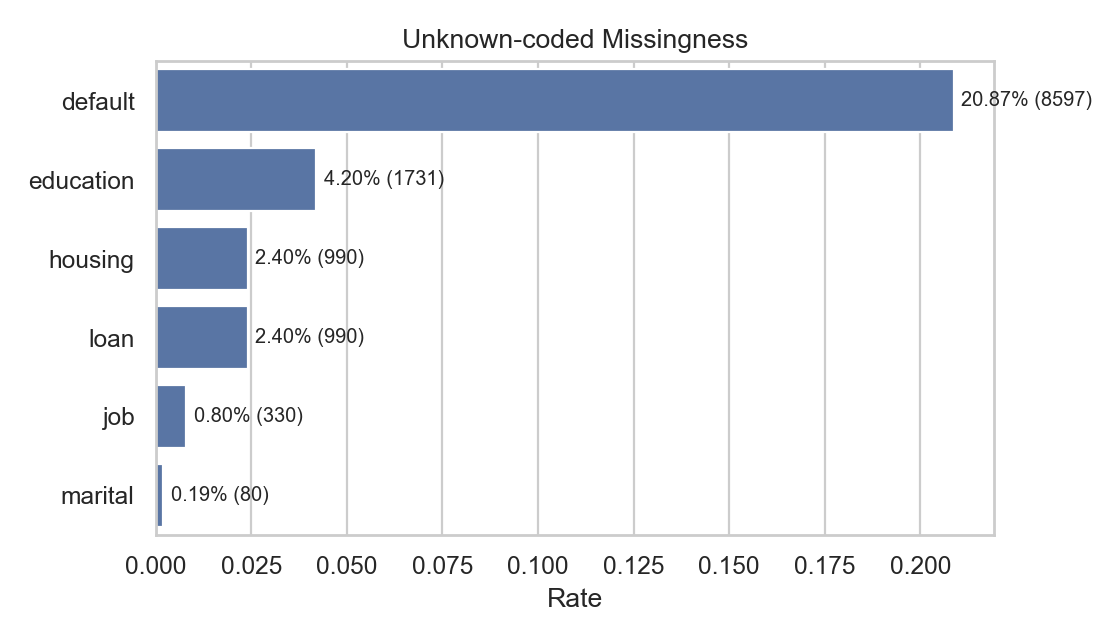

#### Bảng độ lệch và outlier của các biến số

,feature,skew,q1,median,q3,iqr,outlier_count_iqr,outlier_rate_iqr
4,previous,3.8320,0.0000,0.0000,0.0000,0.0000,5625,13.66%
1,duration,3.2631,102.0000,180.0000,319.0000,217.0000,2963,7.19%
2,campaign,4.7625,1.0000,2.0000,3.0000,2.0000,2406,5.84%
3,pdays,-4.9222,999.0000,999.0000,999.0000,0.0000,1515,3.68%
0,age,0.7847,32.0000,38.0000,47.0000,15.0000,469,1.14%
7,cons.conf.idx,0.3032,-42.7000,-41.8000,-36.4000,6.3000,447,1.09%
5,emp.var.rate,-0.7241,-1.8000,1.1000,1.4000,3.2000,0,0.00%
6,cons.price.idx,-0.2309,93.0750,93.7490,93.9940,0.9190,0,0.00%
8,euribor3m,-0.7092,1.3440,4.8570,4.9610,3.6170,0,0.00%
9,nr.employed,-1.0443,5099.1000,5191.0000,5228.1000,129.0000,0,0.00%



### Diễn giải
- `default` có tỷ lệ `unknown` lớn nhất, nên missingness ở đây bản thân nó đã có thể mang thông tin.
- `duration`, `campaign`, `previous` lệch phải mạnh; nếu dùng mô hình nhạy với phân phối và scale thì cần tiền xử lý cẩn thận.
- `pdays` không thể đọc như một biến số thông thường vì phần lớn phân phối bị chi phối bởi mã 999.


In [5]:
duplicate_count = int(raw_df.duplicated().sum())
positive_rate = raw_df["y"].eq("yes").mean()
pdays_999_rate = raw_df["pdays"].eq(999).mean()
unknown_df = summarize_unknowns(raw_df)
outlier_df = summarize_outliers(raw_df, numeric_cols)

plot_unknown_summary(unknown_df)

display(
    Markdown(
        f"""
### Nhận xét nhanh về chất lượng dữ liệu
- Kích thước dữ liệu: **{raw_df.shape[0]:,} dòng x {raw_df.shape[1] - 1} biến đầu vào + 1 biến mục tiêu**.
- Số dòng trùng lặp hoàn toàn: **{duplicate_count}**.
- Không có `NaN` theo kiểu thông thường, nhưng có nhiều giá trị thiếu được mã hoá bằng nhãn `unknown`.
- Tỷ lệ lớp dương `y = yes` chỉ khoảng **{positive_rate:.2%}**, cho thấy dữ liệu bị mất cân bằng.
- Có tới **{pdays_999_rate:.2%}** mẫu có `pdays = 999`; đây là giá trị mã hoá cho trạng thái **chưa từng được liên hệ trước đó**, không phải 999 ngày thực.
"""
    )
)

display(Markdown("#### Bảng `unknown` theo từng biến"))
display(format_table(unknown_df, percent_cols=["unknown_rate"]))

display(Markdown("#### Biểu đồ tỷ lệ `unknown`"))
display(Image(filename=str(FIG_DIR / "unknown_summary.png")))

display(Markdown("#### Bảng độ lệch và outlier của các biến số"))
display(format_table(outlier_df, percent_cols=["outlier_rate_iqr"]))

display(
    Markdown(
        """
### Diễn giải
- `default` có tỷ lệ `unknown` lớn nhất, nên missingness ở đây bản thân nó đã có thể mang thông tin.
- `duration`, `campaign`, `previous` lệch phải mạnh; nếu dùng mô hình nhạy với phân phối và scale thì cần tiền xử lý cẩn thận.
- `pdays` không thể đọc như một biến số thông thường vì phần lớn phân phối bị chi phối bởi mã 999.
"""
    )
)


## 5. Biến mục tiêu và mức độ mất cân bằng lớp

Trước khi đi vào từng biến đầu vào, cần kiểm tra xem bài toán dự đoán có cân bằng hay không vì điều này ảnh hưởng trực tiếp tới cách đánh giá mô hình.

,y,count,share
0,no,36548,0.887346
1,yes,4640,0.112654


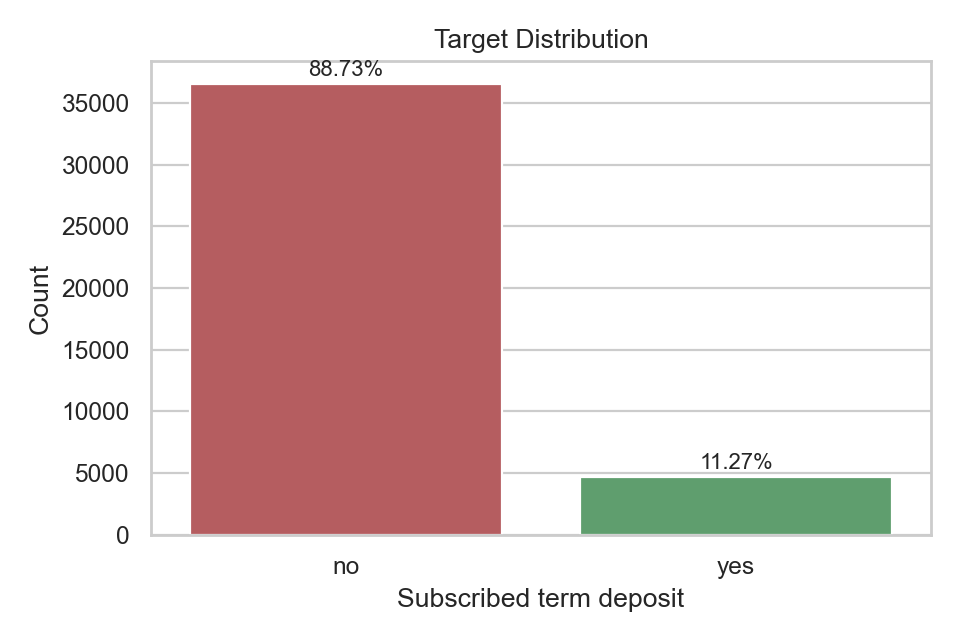


### Kết luận cho biến mục tiêu
- Lớp `no`: **36,548** mẫu.
- Lớp `yes`: **4,640** mẫu.
- Vì lớp dương chỉ chiếm **11.27%**, không nên chỉ nhìn mỗi `Accuracy`.
- Với bộ dữ liệu này, nên ưu tiên các chỉ số như **ROC-AUC**, **PR-AUC**, **F1 cho lớp `yes`** và **Balanced Accuracy**.


In [6]:
target_counts = raw_df["y"].value_counts().rename_axis("y").reset_index(name="count")
target_counts["share"] = target_counts["count"] / target_counts["count"].sum()

plot_target_distribution(raw_df)

display(target_counts)
display(Image(filename=str(FIG_DIR / "target_distribution.png")))

display(
    Markdown(
        f"""
### Kết luận cho biến mục tiêu
- Lớp `no`: **{int((raw_df["y"] == "no").sum()):,}** mẫu.
- Lớp `yes`: **{int((raw_df["y"] == "yes").sum()):,}** mẫu.
- Vì lớp dương chỉ chiếm **{positive_rate:.2%}**, không nên chỉ nhìn mỗi `Accuracy`.
- Với bộ dữ liệu này, nên ưu tiên các chỉ số như **ROC-AUC**, **PR-AUC**, **F1 cho lớp `yes`** và **Balanced Accuracy**.
"""
    )
)


## 6. Quan hệ giữa các biến phân loại và biến mục tiêu

Mục tiêu của phần này là tìm ra các biến phân loại nào có mối liên hệ mạnh với `y`, và mức độ mạnh yếu đó đủ lớn đến đâu để tác động tới lựa chọn mô hình.

#### Độ mạnh liên hệ (Cramer's V)

,feature,n_levels,cramers_v
9,poutcome,3,0.3204
7,month,10,0.2740
0,job,12,0.1519
6,contact,2,0.1446
3,default,3,0.0991
2,education,8,0.0672
1,marital,4,0.0539
8,day_of_week,5,0.0232
4,housing,3,0.0095
5,loan,3,0.0000


#### Biểu đồ tỷ lệ `yes` theo các biến phân loại quan trọng

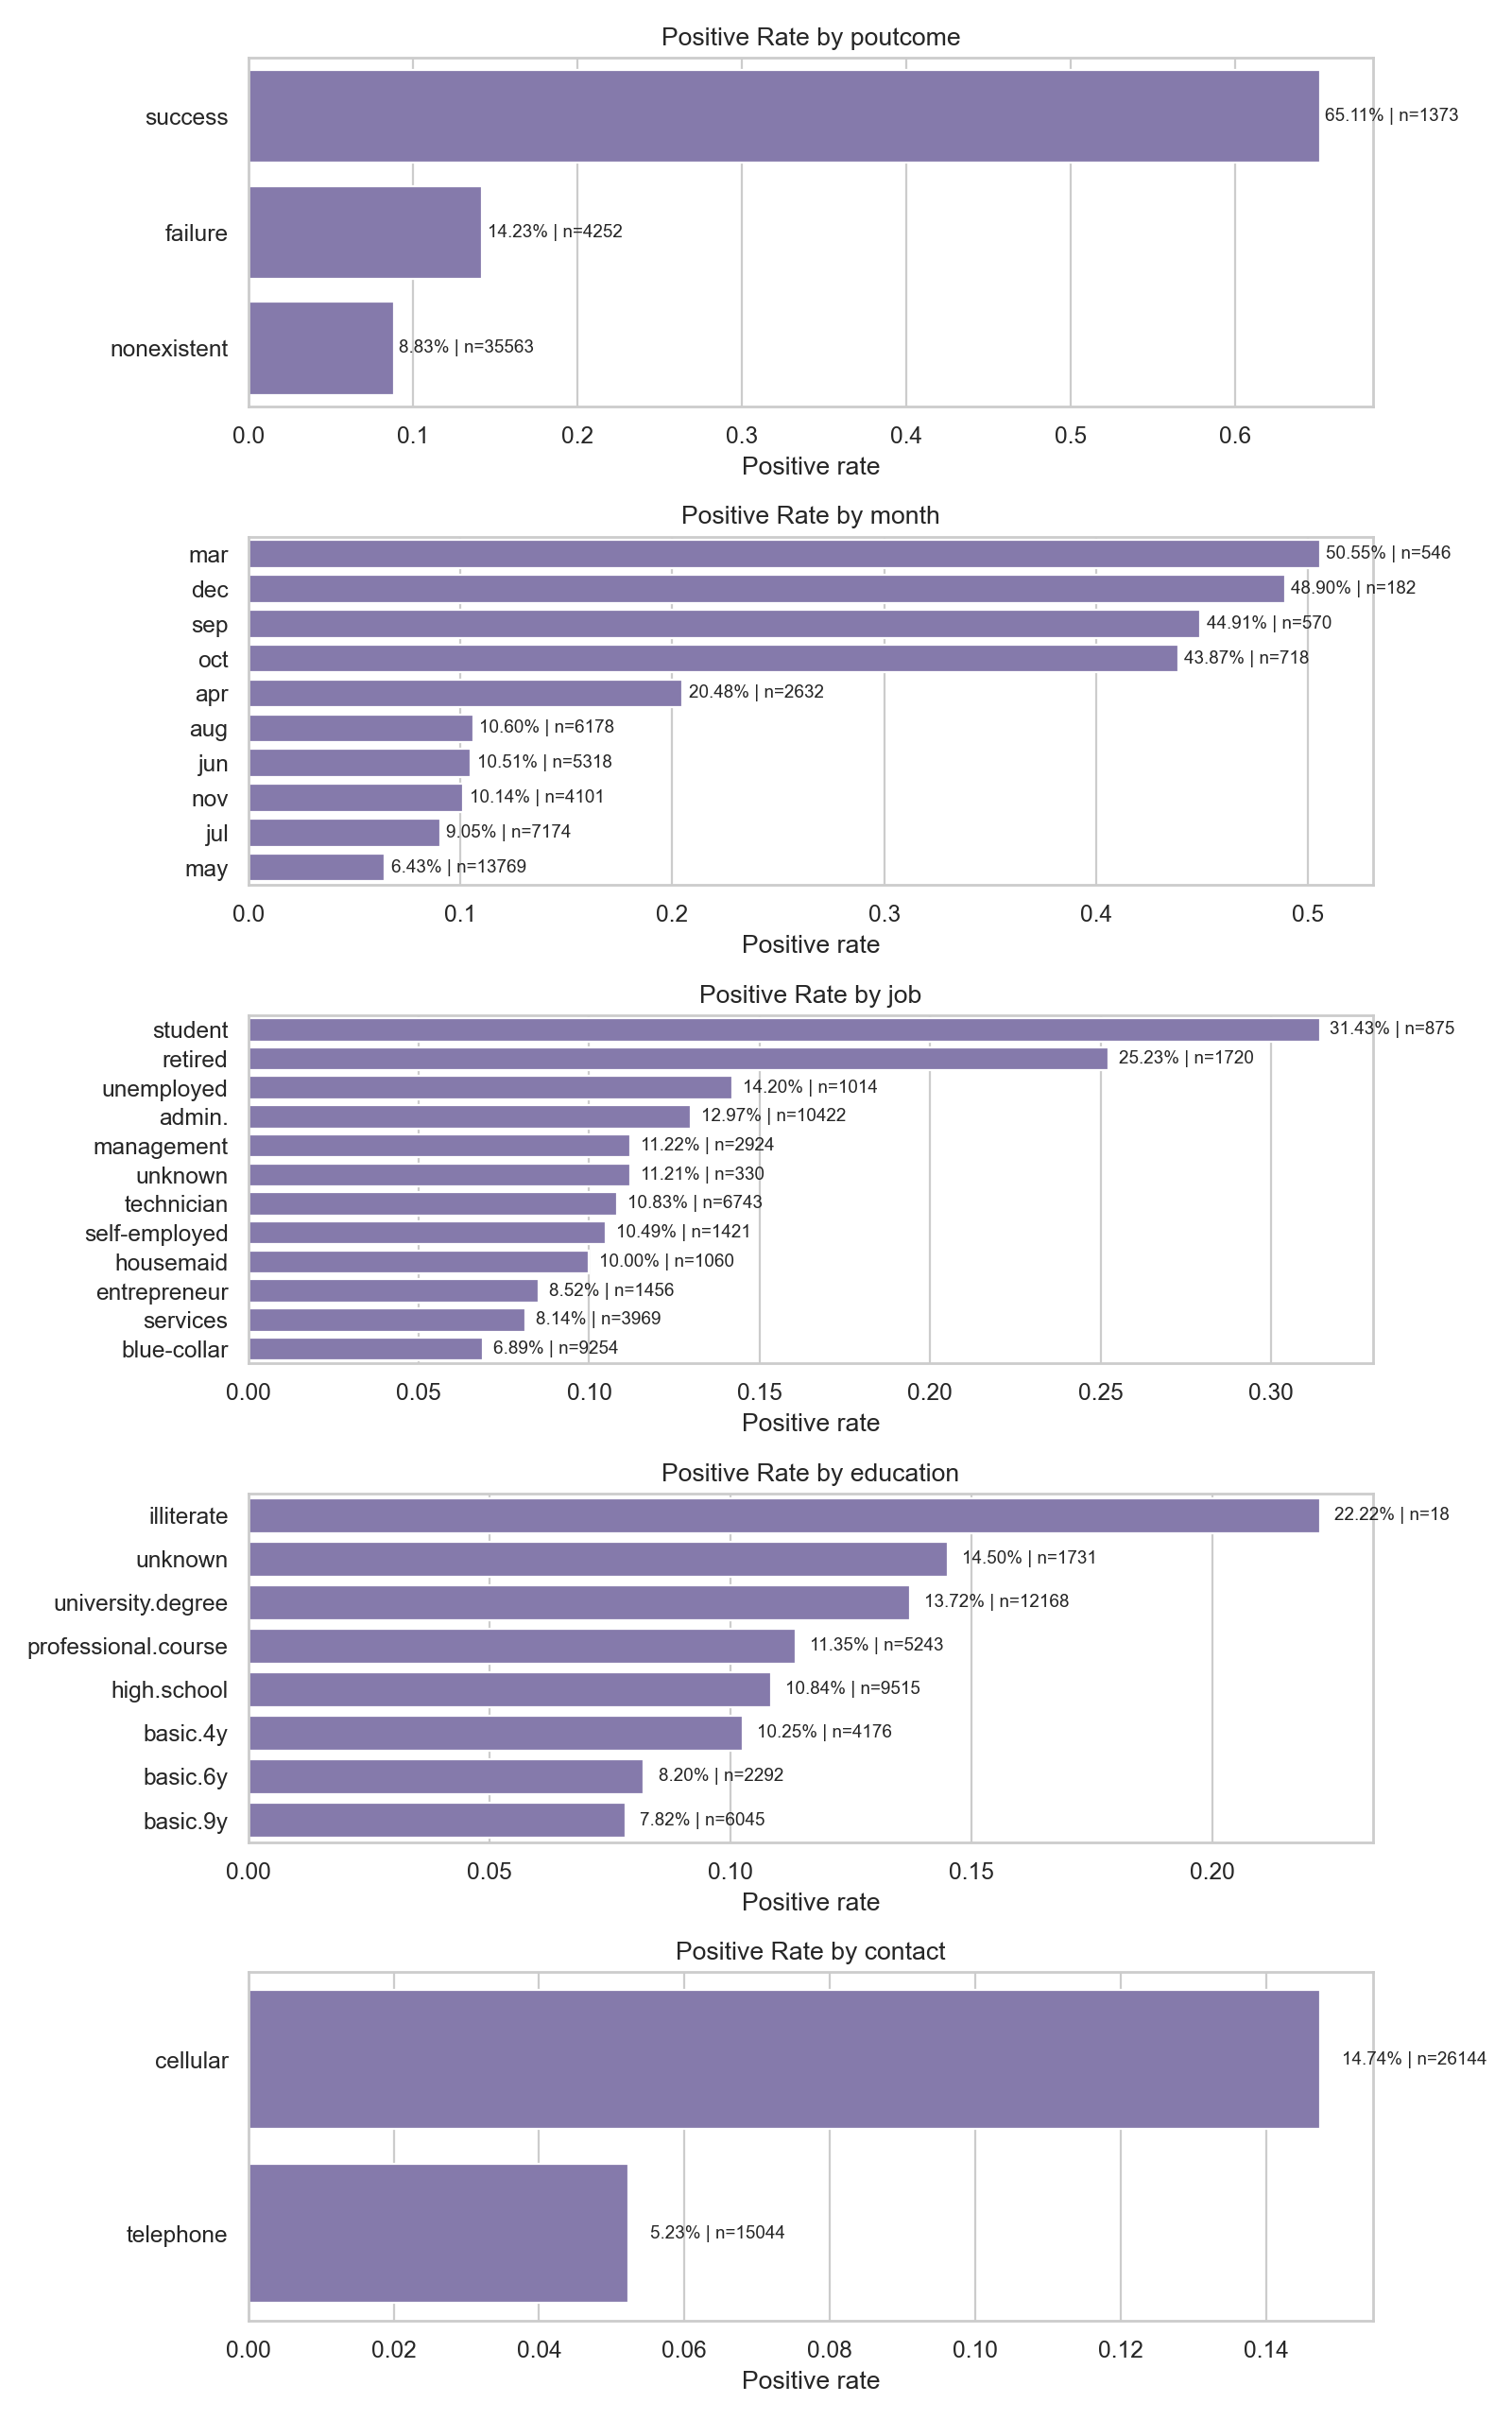

#### Bảng theo `contact`

,contact,positive_rate,count
0,cellular,14.74%,26144
1,telephone,5.23%,15044


#### Bảng theo `poutcome`

,poutcome,positive_rate,count
0,success,65.11%,1373
1,failure,14.23%,4252
2,nonexistent,8.83%,35563


#### Bảng theo `month`

...

#### Bảng theo `job`

,job,positive_rate,count
0,student,31.43%,875
1,retired,25.23%,1720
2,unemployed,14.20%,1014
3,admin.,12.97%,10422
4,management,11.22%,2924
5,unknown,11.21%,330
6,technician,10.83%,6743
7,self-employed,10.49%,1421
8,housemaid,10.00%,1060
9,entrepreneur,8.52%,1456


#### Bảng theo `education`

,education,positive_rate,count
0,illiterate,22.22%,18
1,unknown,14.50%,1731
2,university.degree,13.72%,12168
3,professional.course,11.35%,5243
4,high.school,10.84%,9515
5,basic.4y,10.25%,4176
6,basic.6y,8.20%,2292
7,basic.9y,7.82%,6045



### Diễn giải chính
- `poutcome` là biến phân loại mạnh nhất theo Cramer's V. Đặc biệt, nhóm `poutcome = success` có tỷ lệ chuyển đổi **65.11%**.
- `contact` cũng có tín hiệu rõ: `cellular` tốt hơn `telephone` khá nhiều.
- `month` thay đổi mạnh theo mùa và theo giai đoạn chiến dịch, cho thấy khả năng có **seasonality** hoặc **temporal drift**.
- `job` và `education` cho thấy dữ liệu có phân khúc khách hàng rõ ràng, không phải mọi nhóm khách hàng đều phản ứng giống nhau.
- Kết quả này là một dấu hiệu sớm cho thấy mô hình phi tuyến hoặc mô hình có khả năng học tương tác sẽ có lợi thế so với mô hình tuyến tính thuần tuý.


In [7]:
categorical_assoc_df = categorical_association(raw_df, categorical_cols)
contact_rates = positive_rate_table(raw_df, "contact")
poutcome_rates = positive_rate_table(raw_df, "poutcome")
month_rates = positive_rate_table(raw_df, "month")
job_rates = positive_rate_table(raw_df, "job")
education_rates = positive_rate_table(raw_df, "education")

plot_positive_rate_bars(
    raw_df,
    feature_specs=[
        ("poutcome", 3),
        ("month", 10),
        ("job", 12),
        ("education", 8),
        ("contact", 2),
    ],
)

display(Markdown("#### Độ mạnh liên hệ (Cramer's V)"))
display(format_table(categorical_assoc_df, float_digits=4))

display(Markdown("#### Biểu đồ tỷ lệ `yes` theo các biến phân loại quan trọng"))
display(Image(filename=str(FIG_DIR / "positive_rate_by_category.png")))

display(Markdown("#### Bảng theo `contact`"))
display(format_table(contact_rates, percent_cols=["positive_rate"]))

display(Markdown("#### Bảng theo `poutcome`"))
display(format_table(poutcome_rates, percent_cols=["positive_rate"]))

display(Markdown("#### Bảng theo `month`"))
display(format_table(month_rates, percent_cols=["positive_rate"]))

display(Markdown("#### Bảng theo `job`"))
display(format_table(job_rates, percent_cols=["positive_rate"]))

display(Markdown("#### Bảng theo `education`"))
display(format_table(education_rates, percent_cols=["positive_rate"]))

display(
    Markdown(
        f"""
### Diễn giải chính
- `poutcome` là biến phân loại mạnh nhất theo Cramer's V. Đặc biệt, nhóm `poutcome = success` có tỷ lệ chuyển đổi **{poutcome_rates.loc[poutcome_rates["poutcome"] == "success", "positive_rate"].iloc[0]:.2%}**.
- `contact` cũng có tín hiệu rõ: `cellular` tốt hơn `telephone` khá nhiều.
- `month` thay đổi mạnh theo mùa và theo giai đoạn chiến dịch, cho thấy khả năng có **seasonality** hoặc **temporal drift**.
- `job` và `education` cho thấy dữ liệu có phân khúc khách hàng rõ ràng, không phải mọi nhóm khách hàng đều phản ứng giống nhau.
- Kết quả này là một dấu hiệu sớm cho thấy mô hình phi tuyến hoặc mô hình có khả năng học tương tác sẽ có lợi thế so với mô hình tuyến tính thuần tuý.
"""
    )
)


## 7. Quan hệ giữa các biến số và biến mục tiêu

Ở phần này ta kiểm tra các biến số quan trọng để xem liệu chúng có quan hệ tuyến tính đơn giản hay có dạng ngưỡng, lệch mạnh hoặc phi tuyến.

#### Độ mạnh liên hệ của các biến số với `y`

,feature,pearson_with_y,mutual_information
1,duration,0.4053,0.0763
8,euribor3m,-0.3078,0.0742
7,cons.conf.idx,0.0549,0.0707
6,cons.price.idx,-0.1362,0.0694
9,nr.employed,-0.3547,0.0659
5,emp.var.rate,-0.2983,0.0577
3,pdays,-0.3249,0.0400
4,previous,0.2302,0.0199
0,age,0.0304,0.0127
2,campaign,-0.0664,0.0042


#### Biểu đồ xu hướng của một số biến số quan trọng

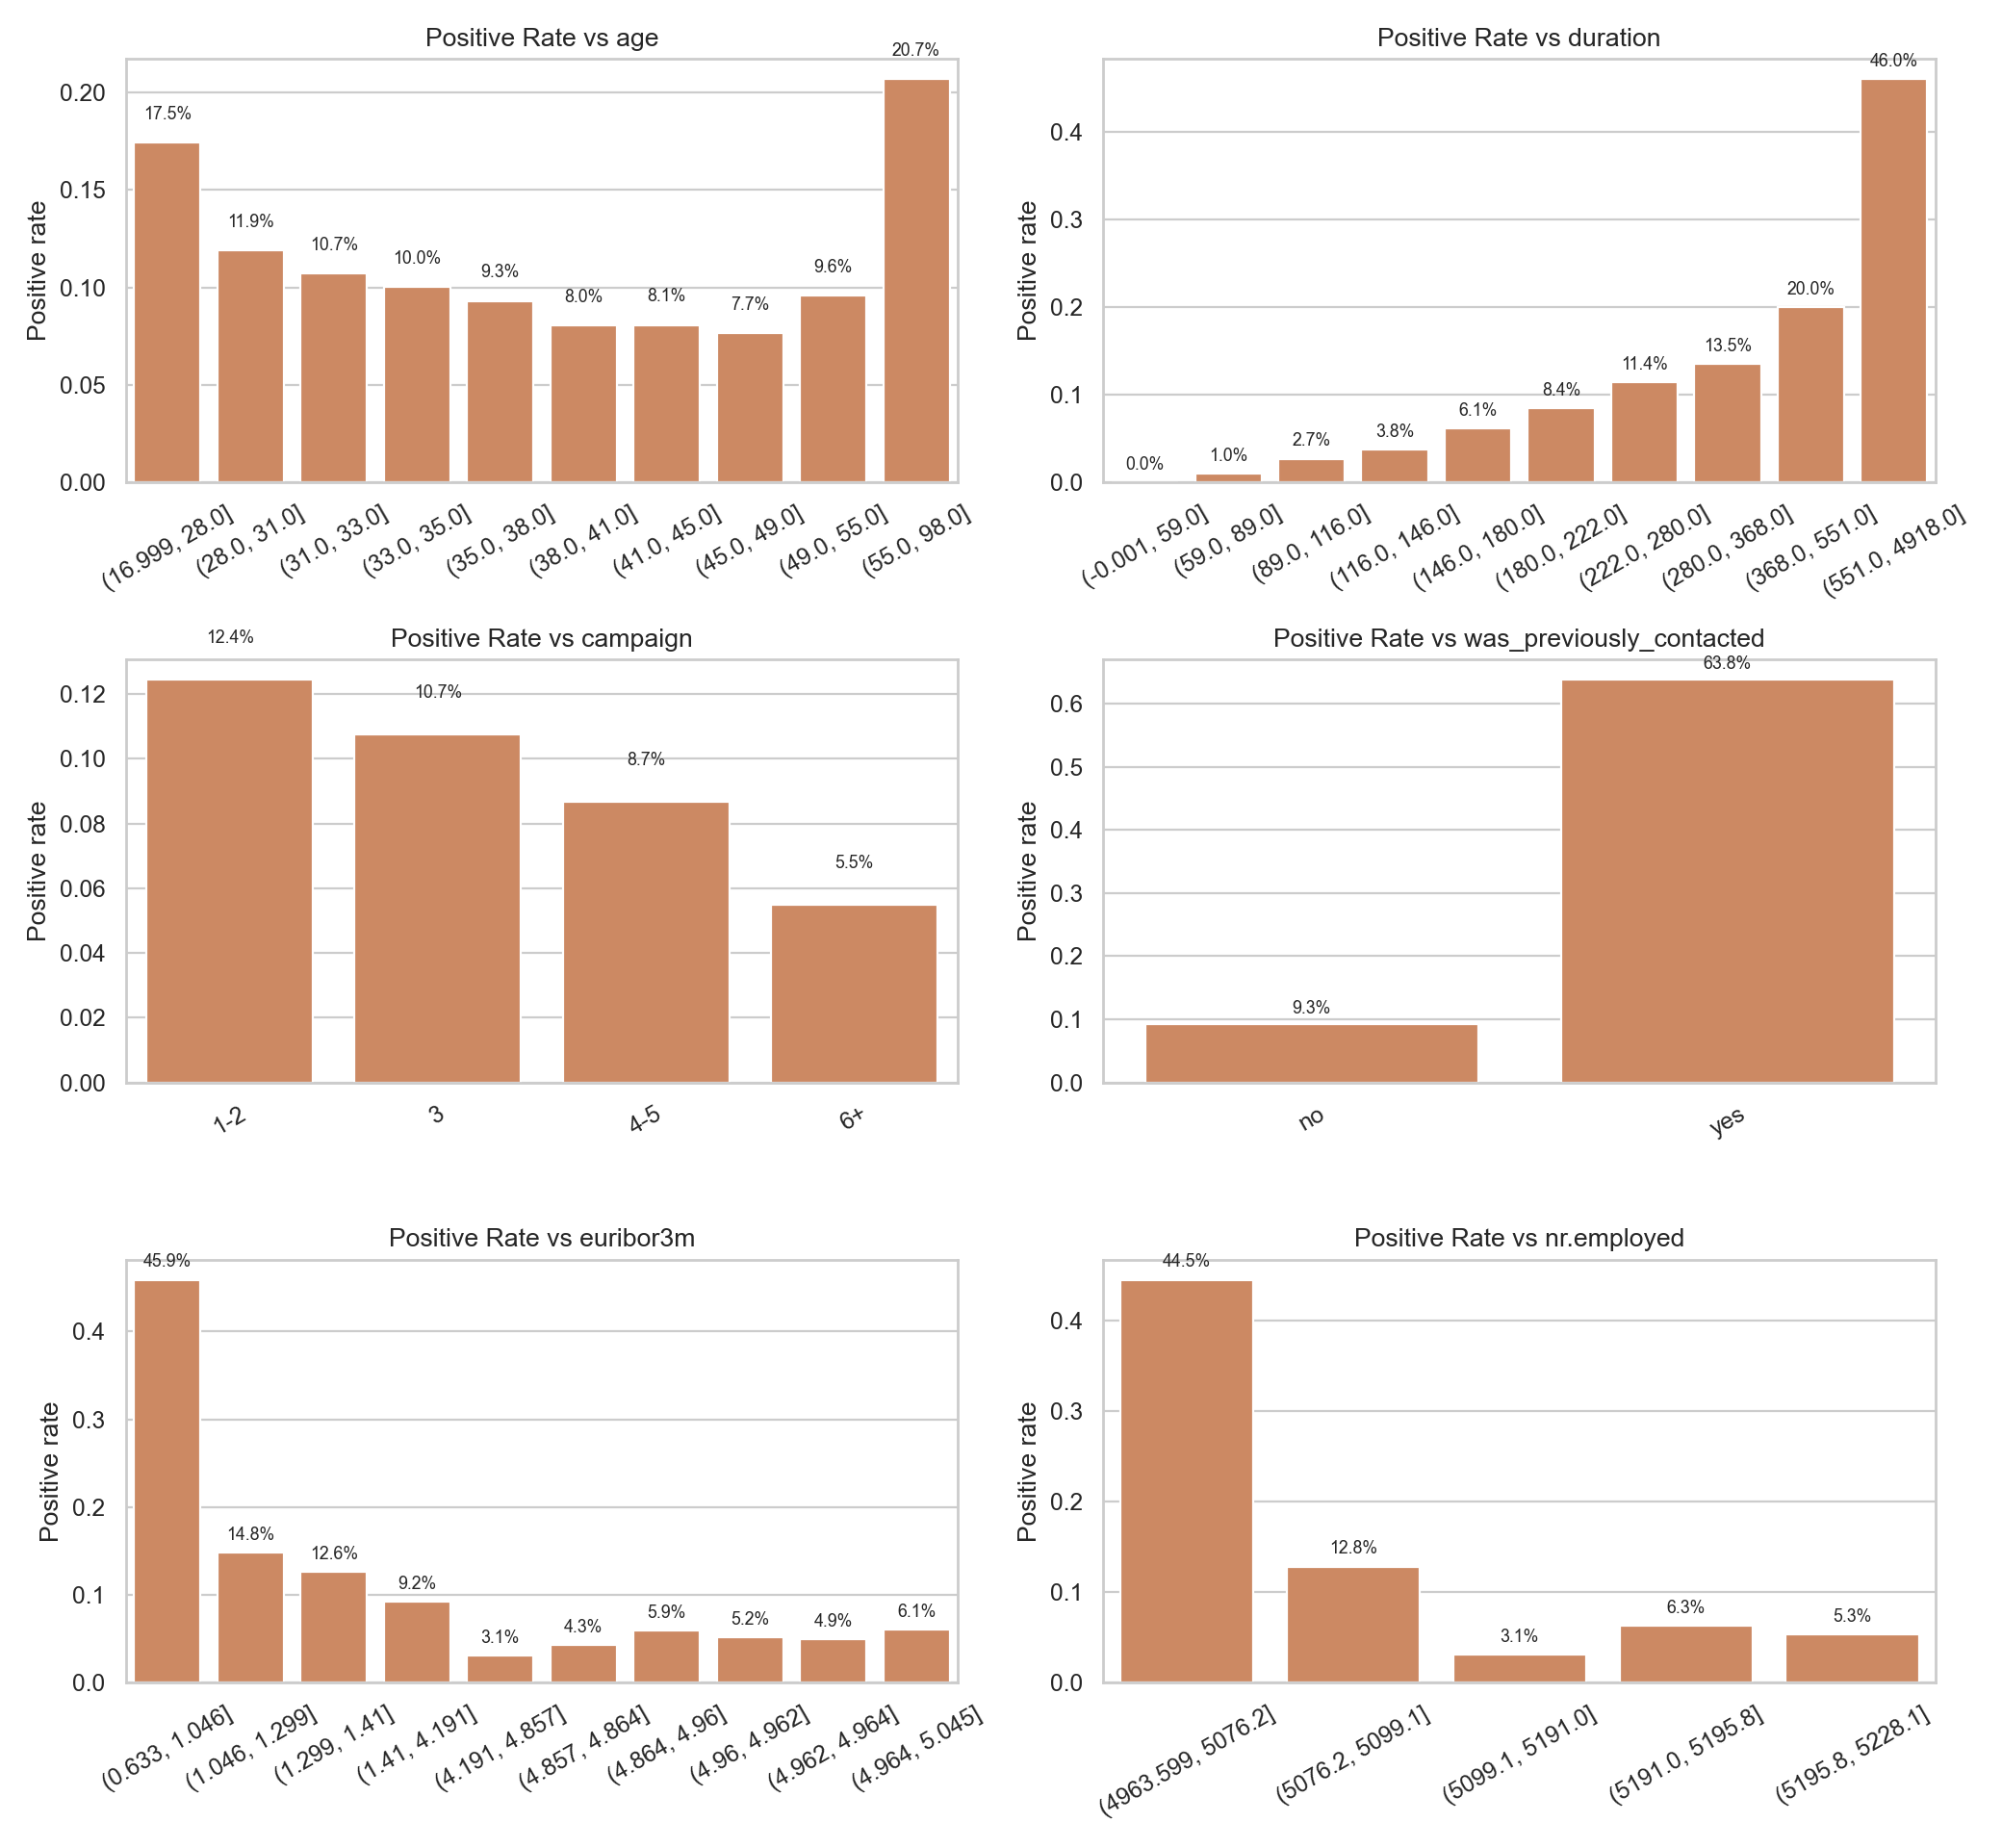

#### Phân vị của `age`

,bin,positive_rate,count
0,"(16.999, 28.0]",17.46%,4216
1,"(28.0, 31.0]",11.89%,5114
2,"(31.0, 33.0]",10.71%,3679
3,"(33.0, 35.0]",10.02%,3504
4,"(35.0, 38.0]",9.31%,4662
5,"(38.0, 41.0]",8.03%,3871
6,"(41.0, 45.0]",8.07%,4311
7,"(45.0, 49.0]",7.65%,3776
8,"(49.0, 55.0]",9.57%,4473
9,"(55.0, 98.0]",20.69%,3582


#### Phân vị của `duration`

,bin,positive_rate,count
0,"(-0.001, 59.0]",0.02%,4181
1,"(59.0, 89.0]",1.02%,4207
2,"(89.0, 116.0]",2.68%,3987
3,"(116.0, 146.0]",3.78%,4152
4,"(146.0, 180.0]",6.13%,4178
5,"(180.0, 222.0]",8.45%,4096
6,"(222.0, 280.0]",11.40%,4062
7,"(280.0, 368.0]",13.50%,4103
8,"(368.0, 551.0]",20.01%,4118
9,"(551.0, 4918.0]",46.03%,4104


#### Trạng thái đã từng được liên hệ trước đó hay chưa

,was_previously_contacted,positive_rate,count
0,no,9.26%,39673
1,yes,63.83%,1515



### Diễn giải chính
- `duration` là biến số mạnh nhất về mặt dự đoán, nhưng đây là **leakage / benchmark feature** hơn là biến hợp lệ cho mô hình thực tế.
- `age` không tăng hay giảm đều theo một đường thẳng; nó có xu hướng **hơi chữ U**, nghĩa là mô hình tuyến tính đơn giản có thể bỏ sót cấu trúc này.
- `campaign` có xu hướng âm: liên hệ quá nhiều lần trong cùng một chiến dịch thì xác suất đăng ký giảm.
- Nếu `pdays = 999` thì tỷ lệ `yes` chỉ khoảng **9.26%**; còn nếu khách đã từng được liên hệ trước đó thì tỷ lệ `yes` tăng lên **63.83%**.
- Nhóm biến vĩ mô như `euribor3m`, `nr.employed`, `emp.var.rate` cũng mạnh, nhưng ta sẽ cần kiểm tra thêm đa cộng tuyến vì nhiều khả năng chúng đồng biến với nhau.


In [8]:
numeric_assoc_df = numeric_association(raw_df, numeric_cols)
age_bins = quantile_target_rate(raw_df, "age")
duration_bins = quantile_target_rate(raw_df, "duration")
previous_contact_df = custom_binary_target_rate(
    raw_df,
    "was_previously_contacted",
    raw_df["pdays"] != 999,
)

plot_numeric_target_rate(raw_df)

display(Markdown("#### Độ mạnh liên hệ của các biến số với `y`"))
display(format_table(numeric_assoc_df, float_digits=4))

display(Markdown("#### Biểu đồ xu hướng của một số biến số quan trọng"))
display(Image(filename=str(FIG_DIR / "numeric_target_rate_patterns.png")))

display(Markdown("#### Phân vị của `age`"))
display(format_table(age_bins, percent_cols=["positive_rate"]))

display(Markdown("#### Phân vị của `duration`"))
display(format_table(duration_bins, percent_cols=["positive_rate"]))

display(Markdown("#### Trạng thái đã từng được liên hệ trước đó hay chưa"))
display(format_table(previous_contact_df, percent_cols=["positive_rate"]))

pdays_999_success = raw_df.loc[raw_df["pdays"] == 999, "y"].eq("yes").mean()
pdays_contacted_success = raw_df.loc[raw_df["pdays"] != 999, "y"].eq("yes").mean()

display(
    Markdown(
        f"""
### Diễn giải chính
- `duration` là biến số mạnh nhất về mặt dự đoán, nhưng đây là **leakage / benchmark feature** hơn là biến hợp lệ cho mô hình thực tế.
- `age` không tăng hay giảm đều theo một đường thẳng; nó có xu hướng **hơi chữ U**, nghĩa là mô hình tuyến tính đơn giản có thể bỏ sót cấu trúc này.
- `campaign` có xu hướng âm: liên hệ quá nhiều lần trong cùng một chiến dịch thì xác suất đăng ký giảm.
- Nếu `pdays = 999` thì tỷ lệ `yes` chỉ khoảng **{pdays_999_success:.2%}**; còn nếu khách đã từng được liên hệ trước đó thì tỷ lệ `yes` tăng lên **{pdays_contacted_success:.2%}**.
- Nhóm biến vĩ mô như `euribor3m`, `nr.employed`, `emp.var.rate` cũng mạnh, nhưng ta sẽ cần kiểm tra thêm đa cộng tuyến vì nhiều khả năng chúng đồng biến với nhau.
"""
    )
)


## 8. Cấu trúc đa biến, quan hệ giữa các data points và drift theo thời gian

Đây là phần rất quan trọng cho yêu cầu "phải show ra được quan hệ của data points". Ta sẽ nhìn từ 3 góc:

- Tương quan và đa cộng tuyến giữa các biến số.
- Drift theo thứ tự thời gian của bộ dữ liệu.
- Hình chiếu PCA để xem các data points của hai lớp có tách nhau rõ hay không.

#### Heatmap tương quan của các biến số

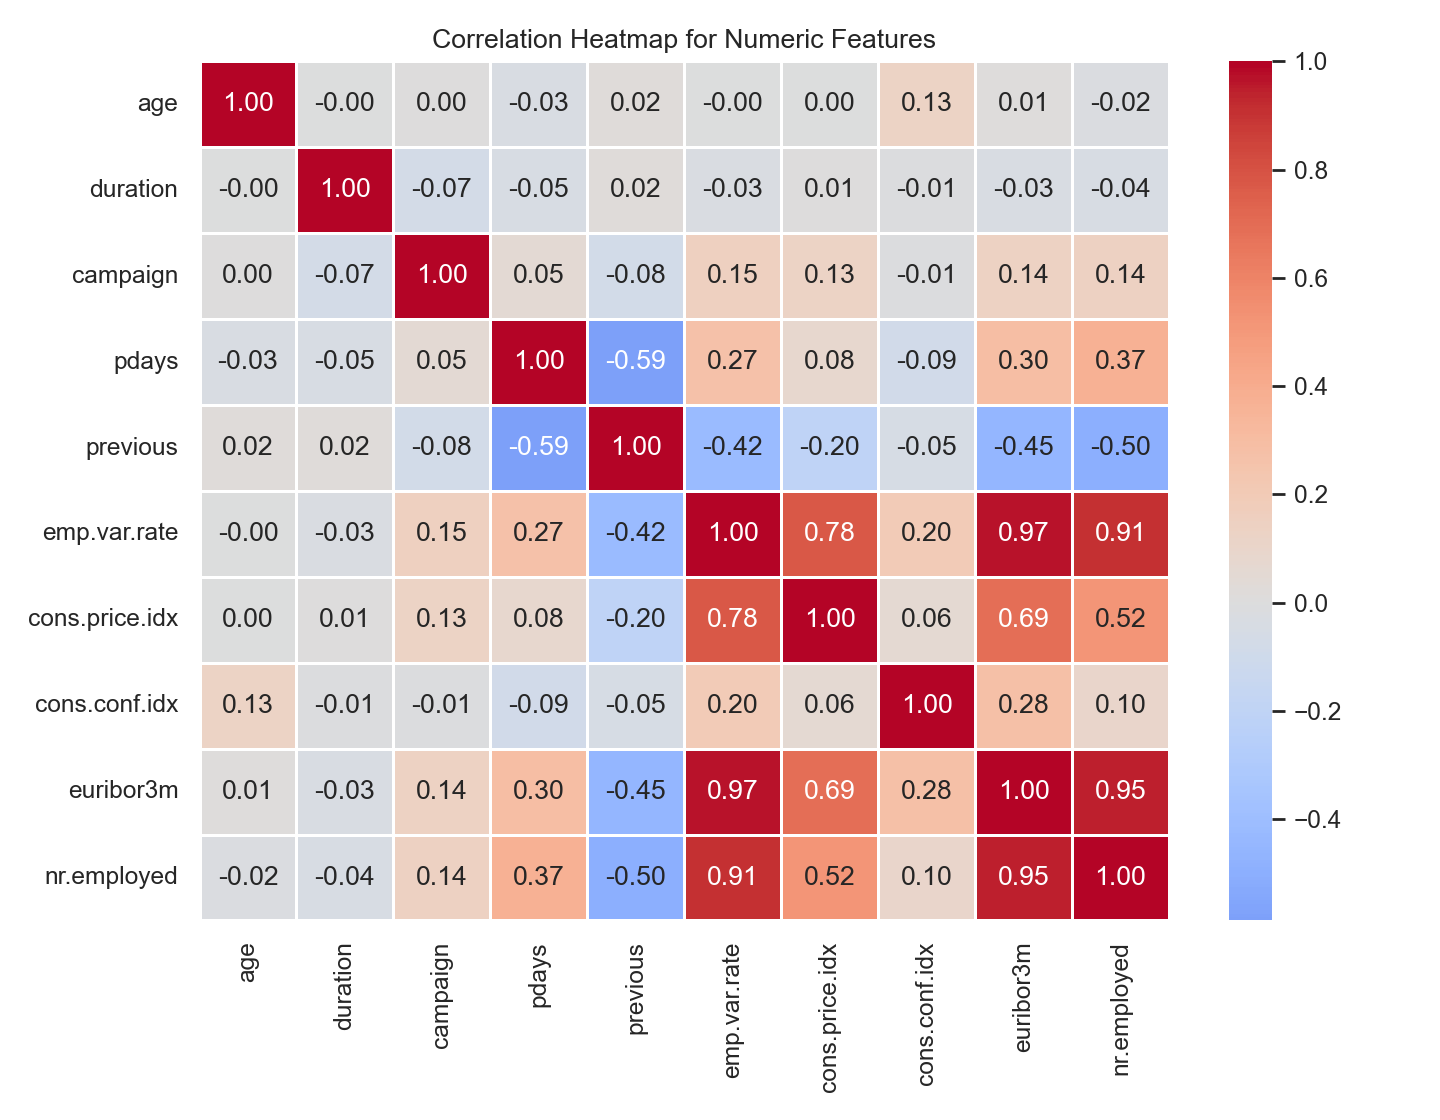

#### Bảng VIF

,feature,vif
8,euribor3m,64.350
5,emp.var.rate,33.070
9,nr.employed,31.676
6,cons.price.idx,6.338
7,cons.conf.idx,2.650
4,previous,1.797
3,pdays,1.615
2,campaign,1.038
0,age,1.019
1,duration,1.009


#### Drift theo các phân đoạn thời gian

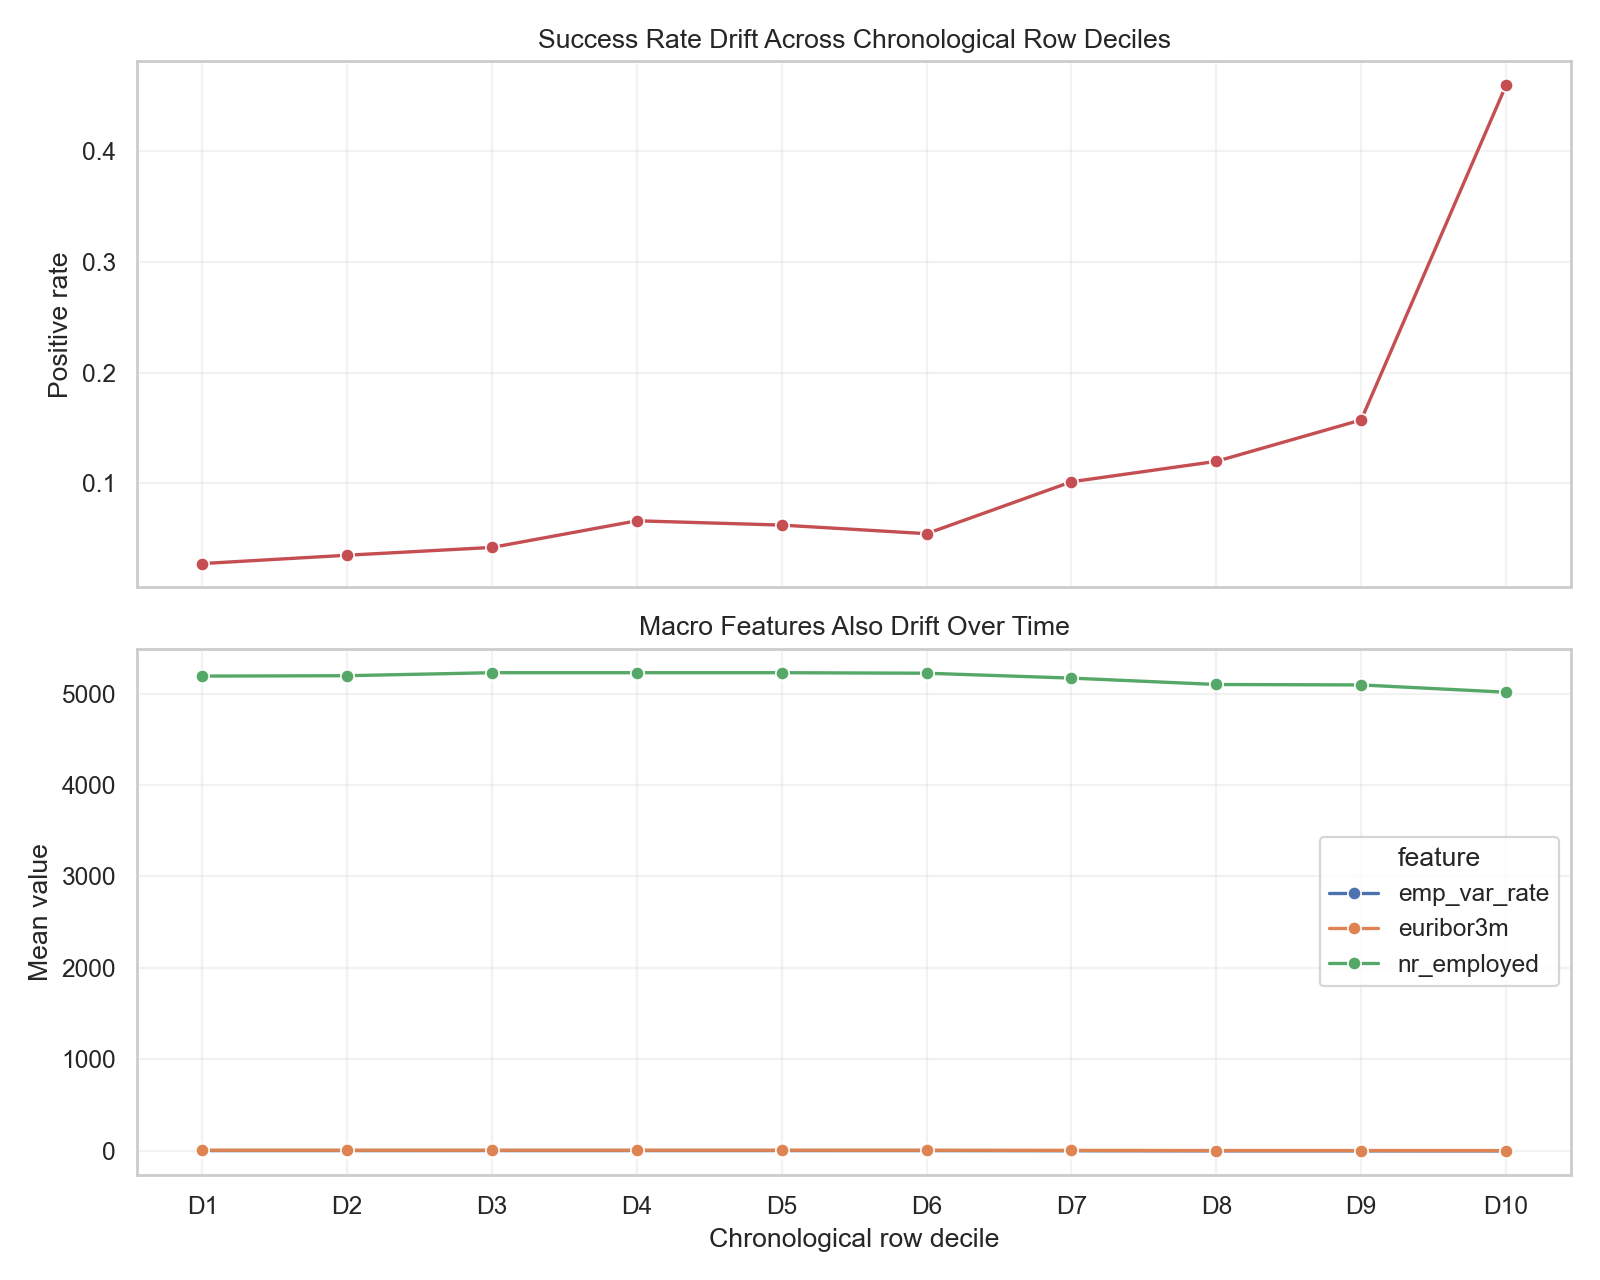

,row_decile,positive_rate,emp_var_rate,euribor3m,nr_employed
0,D1,2.77%,1.1000,4.8572,5191.0000
1,D2,3.52%,1.1346,4.8590,5195.2783
2,D3,4.22%,1.4000,4.9409,5228.1000
3,D4,6.63%,1.4000,4.9607,5228.1000
4,D5,6.24%,1.4000,4.9649,5228.1000
5,D6,5.46%,1.1393,4.8450,5222.4853
6,D7,10.15%,-0.5713,3.3704,5168.9594
7,D8,11.99%,-1.8000,1.3537,5099.1000
8,D9,15.73%,-2.0257,1.2599,5094.4021
9,D10,45.93%,-2.3579,0.8016,5014.8492


#### Hình chiếu PCA của các data points (không dùng duration)

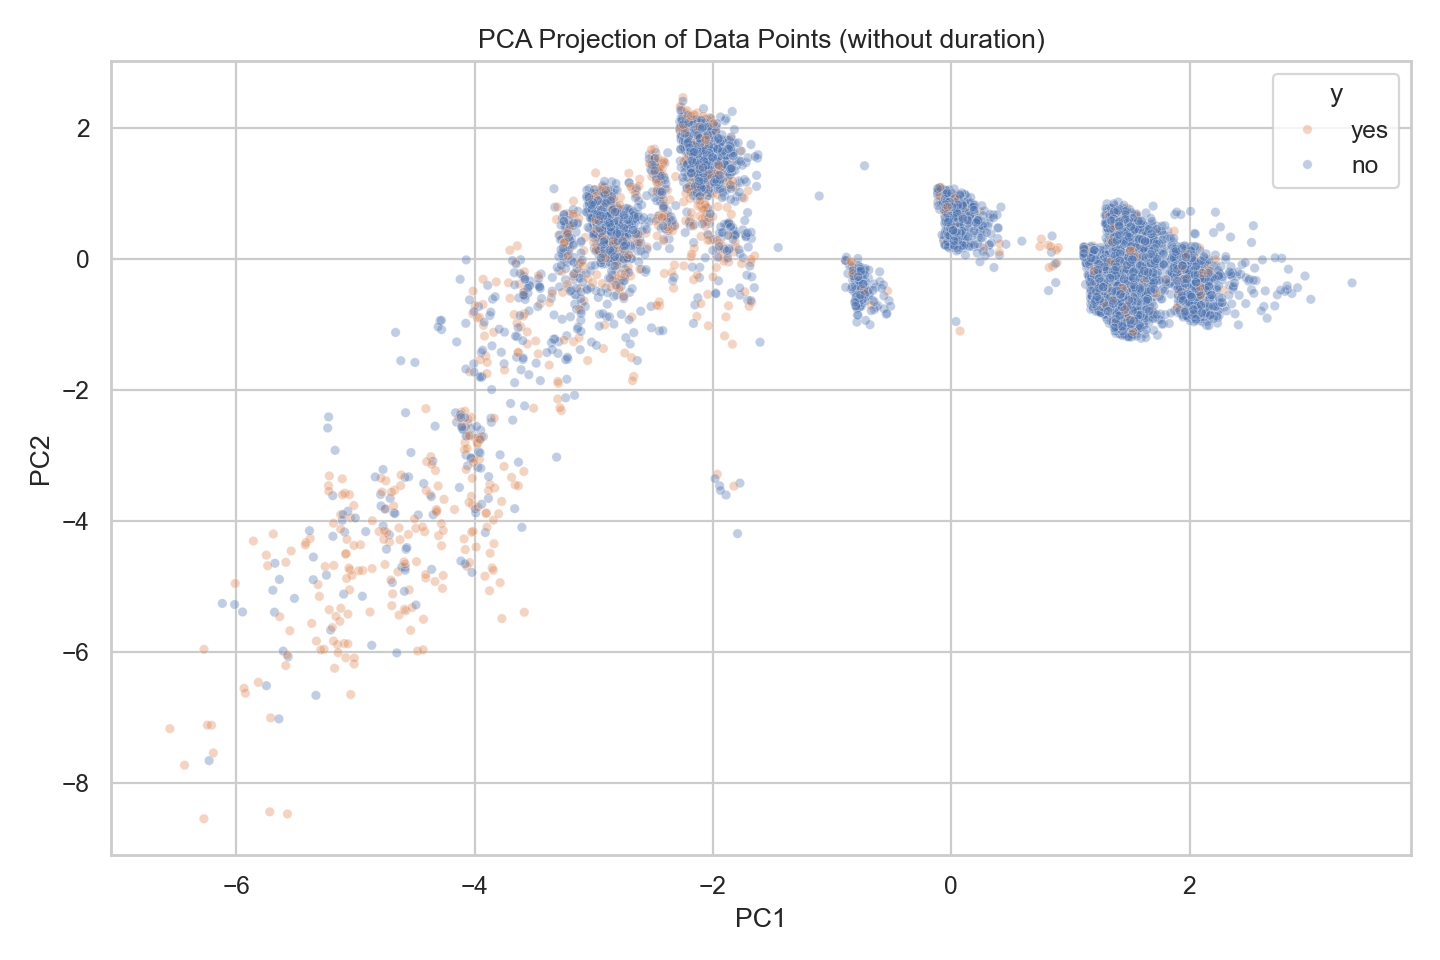


### Diễn giải chính
- Nhóm biến vĩ mô có **đa cộng tuyến rất mạnh**, đặc biệt là `euribor3m`, `emp.var.rate` và `nr.employed`.
- Điều này có nghĩa là nếu dùng mô hình tuyến tính, cần **regularization** và cần cẩn thận khi diễn giải hệ số từng biến riêng lẻ.
- Tỷ lệ thành công theo thứ tự thời gian tăng từ **2.77%** lên **45.93%**, đây là dấu hiệu rất rõ của **concept drift / temporal drift**.
- PCA cho thấy hai lớp có khác biệt, nhưng **không tách thành hai cụm sạch sẽ**. Nói cách khác, dữ liệu không phải là một bài toán tuyến tính rất đẹp; nó có chồng lấp đáng kể giữa các data points.
- Chính điểm này giải thích vì sao các mô hình phi tuyến như Random Forest hoặc Gradient Boosting có cơ hội vượt baseline tuyến tính.
- PC1 + PC2 giải thích **37.87%** phương sai; 5 thành phần đầu giải thích **58.99%**; silhouette score trên 2 PC là **0.3037**.


In [9]:
vif_df = compute_vif(raw_df, numeric_cols)
plot_correlation_heatmap(raw_df, numeric_cols)
time_drift_df = plot_time_drift(raw_df)
pca_stats = plot_pca_projection(raw_df)

display(Markdown("#### Heatmap tương quan của các biến số"))
display(Image(filename=str(FIG_DIR / "numeric_correlation_heatmap.png")))

display(Markdown("#### Bảng VIF"))
display(format_table(vif_df, float_digits=3))

display(Markdown("#### Drift theo các phân đoạn thời gian"))
display(Image(filename=str(FIG_DIR / "time_drift.png")))
display(format_table(time_drift_df, float_digits=4, percent_cols=["positive_rate"]))

display(Markdown("#### Hình chiếu PCA của các data points (không dùng duration)"))
display(Image(filename=str(FIG_DIR / "pca_projection.png")))

display(
    Markdown(
        f"""
### Diễn giải chính
- Nhóm biến vĩ mô có **đa cộng tuyến rất mạnh**, đặc biệt là `euribor3m`, `emp.var.rate` và `nr.employed`.
- Điều này có nghĩa là nếu dùng mô hình tuyến tính, cần **regularization** và cần cẩn thận khi diễn giải hệ số từng biến riêng lẻ.
- Tỷ lệ thành công theo thứ tự thời gian tăng từ **{time_drift_df["positive_rate"].min():.2%}** lên **{time_drift_df["positive_rate"].max():.2%}**, đây là dấu hiệu rất rõ của **concept drift / temporal drift**.
- PCA cho thấy hai lớp có khác biệt, nhưng **không tách thành hai cụm sạch sẽ**. Nói cách khác, dữ liệu không phải là một bài toán tuyến tính rất đẹp; nó có chồng lấp đáng kể giữa các data points.
- Chính điểm này giải thích vì sao các mô hình phi tuyến như Random Forest hoặc Gradient Boosting có cơ hội vượt baseline tuyến tính.
- PC1 + PC2 giải thích **{pca_stats["pc1_pc2_var"]:.2%}** phương sai; 5 thành phần đầu giải thích **{pca_stats["pc1_to_pc5_var"]:.2%}**; silhouette score trên 2 PC là **{pca_stats["silhouette"]:.4f}**.
"""
    )
)


## 9. Benchmark nhanh để định hướng chọn mô hình

Phần này em làm để hỗ trợ nhóm chọn model và trả lời các câu hỏi:

- Nếu dữ liệu gần tuyến tính thì Logistic Regression có đủ tốt không?
- Nếu bỏ `duration` thì hiệu năng thay đổi bao nhiêu?
- Nếu đánh giá theo thời gian thay vì random split thì mô hình nào bền hơn?

In [10]:
benchmark_parts = []
for split_type in ["random", "time"]:
    for include_duration in [True, False]:
        benchmark_parts.append(
            evaluate_models(raw_df, split_type=split_type, include_duration=include_duration)
        )
benchmark_df = pd.concat(benchmark_parts, ignore_index=True)

strongest_time_no_duration = benchmark_df[
    (benchmark_df["split_type"] == "time") & (~benchmark_df["include_duration"])
].sort_values("roc_auc", ascending=False).head(1)

strongest_random_no_duration = benchmark_df[
    (benchmark_df["split_type"] == "random") & (~benchmark_df["include_duration"])
].sort_values("roc_auc", ascending=False).head(1)

strongest_time_with_duration = benchmark_df[
    (benchmark_df["split_type"] == "time") & (benchmark_df["include_duration"])
].sort_values("roc_auc", ascending=False).head(1)

display(Markdown("#### Bảng benchmark tổng hợp"))
display(
    format_table(
        benchmark_df[
            [
                "split_type",
                "include_duration",
                "model",
                "roc_auc",
                "pr_auc",
                "f1_yes_at_0_5",
                "balanced_acc_at_0_5",
            ]
        ],
        float_digits=4,
    )
)

display(Markdown("#### Mô hình mạnh nhất theo từng kịch bản quan trọng"))
display(Markdown("Time split + không `duration`"))
display(
    format_table(
        strongest_time_no_duration[
            ["model", "roc_auc", "pr_auc", "f1_yes_at_0_5", "balanced_acc_at_0_5"]
        ],
        float_digits=4,
    )
)

display(Markdown("Random split + không `duration`"))
display(
    format_table(
        strongest_random_no_duration[
            ["model", "roc_auc", "pr_auc", "f1_yes_at_0_5", "balanced_acc_at_0_5"]
        ],
        float_digits=4,
    )
)

display(Markdown("Time split + có `duration`"))
display(
    format_table(
        strongest_time_with_duration[
            ["model", "roc_auc", "pr_auc", "f1_yes_at_0_5", "balanced_acc_at_0_5"]
        ],
        float_digits=4,
    )
)



#### Bảng benchmark tổng hợp

,split_type,include_duration,model,roc_auc,pr_auc,f1_yes_at_0_5,balanced_acc_at_0_5
0,random,True,GradientBoosting,0.9497,0.6606,0.5975,0.7564
1,random,True,RandomForest,0.9490,0.6650,0.6429,0.8869
2,random,True,LogisticRegression,0.9403,0.5921,0.6013,0.8835
3,random,True,DecisionTree,0.9258,0.5899,0.5914,0.8777
4,random,True,KNN,0.9247,0.5911,0.4840,0.6790
5,random,False,GradientBoosting,0.8093,0.4798,0.3429,0.6084
6,random,False,RandomForest,0.8056,0.4825,0.5215,0.7600
7,random,False,LogisticRegression,0.8002,0.4463,0.4615,0.7496
8,random,False,KNN,0.7832,0.4340,0.3625,0.6168
9,random,False,DecisionTree,0.7786,0.4195,0.3876,0.7292


#### Mô hình mạnh nhất theo từng kịch bản quan trọng

Time split + không `duration`

,model,roc_auc,pr_auc,f1_yes_at_0_5,balanced_acc_at_0_5
15,RandomForest,0.7244,0.5181,0.4786,0.6374


Random split + không `duration`

,model,roc_auc,pr_auc,f1_yes_at_0_5,balanced_acc_at_0_5
5,GradientBoosting,0.8093,0.4798,0.3429,0.6084


Time split + có `duration`

,model,roc_auc,pr_auc,f1_yes_at_0_5,balanced_acc_at_0_5
10,RandomForest,0.8350,0.6294,0.5006,0.6562


### Diễn giải benchmark
- Khi dùng **random split + có `duration`**, điểm rất cao nhưng đó là kịch bản dễ bị lạc quan quá mức.
- Khi **bỏ `duration`**, hiệu năng giảm rõ rệt; đây là bằng chứng trực tiếp rằng `duration` đang mang rất nhiều thông tin hậu nghiệm.
- Khi chuyển sang **time split**, điểm giảm thêm nữa, xác nhận rằng dữ liệu có drift theo thời gian và việc đánh giá bằng random split thôi là chưa đủ.
- Trên **time split + không `duration`**, mô hình tốt nhất theo ROC-AUC là **{strongest_time_no_duration["model"].iloc[0]}**.
- Trên **time split + có `duration`**, mô hình tốt nhất theo ROC-AUC là **{strongest_time_with_duration["model"].iloc[0]}**.
- Vì vậy, cách trình bày hợp lý nhất là dùng **Logistic Regression làm baseline để giải thích**, sau đó dùng **Random Forest / Gradient Boosting** làm mô hình nâng cao để so sánh.
"""

## 10. Kết luận cuối cùng cho phần Data + EDA

### Tóm tắt ngắn gọn
1. Bộ dữ liệu này **không thuần tuyến tính**. Nó có cả tín hiệu tuyến tính lẫn phi tuyến, cùng với nhiều tương tác giữa biến.
2. `duration` là biến rất mạnh nhưng **không nên dùng làm mô hình thực tế** nếu mục tiêu là dự đoán trước khi cuộc gọi kết thúc.
3. Các cụm biến quan trọng nhất gồm: **`poutcome`, `contact`, `month`, `pdays`, `previous`** và nhóm biến kinh tế vĩ mô.
4. Dữ liệu có **mất cân bằng lớp**, **đa cộng tuyến mạnh** trong nhóm biến vĩ mô và **drift theo thời gian** rất rõ.
5. PCA cho thấy các data points của hai lớp có khác biệt nhưng **không tách tuyến tính hoàn toàn**, nên mô hình phi tuyến có lý do để hoạt động tốt hơn.
6. Chiến lược hợp lý cho nhóm là:
   - dùng **Logistic Regression** làm baseline để giải thích;
   - dùng **Random Forest** hoặc **Gradient Boosting** làm mô hình nâng cao;
   - luôn báo cáo **2 kịch bản** có và không có `duration`;
   - và nên có thêm **time split** để tránh kết luận quá lạc quan.